### Transfer Learning

Transfer learning is a machine learning technique where a model developed for a task is reused as the starting point for a model on a second task. It's particularly popular in deep learning where pre-trained models are used as feature extractors or as initialization for fine-tuning on downstream tasks with limited data.

The process begins with a pre-trained model (source model) that has been trained on a large dataset (source domain). This model has already learned useful features from the source domain. Transfer learning adapts this model to work on a new dataset (target domain) for a new task (target task). This adaptation can range from using the pre-trained model as a fixed feature extractor to fine-tuning some or all of its parameters on the new task.

Transfer learning leverages the hierarchical feature learning nature of deep neural networks - early layers capture generic features like edges and textures, while deeper layers learn more task-specific features. By reusing these generic features, transfer learning dramatically reduces the amount of data needed for the target task and speeds up training time.

#### Pros
- **Requires less data** for target task compared to training from scratch
- **Faster training time** as the model has a better starting point
- **Better performance** on small datasets where training from scratch would lead to overfitting
- **Reduces computational resources** needed to develop models for specific tasks
- **Allows knowledge transfer** from data-rich domains to data-poor domains
- **Enables rapid prototyping** and iterative model development

#### Cons
- **Negative transfer** may occur if source and target domains are too dissimilar
- **Suboptimal architecture** for the target task as the model was designed for another purpose
- **Storage and computational overhead** of using large pre-trained models
- **Limited customization** when using models as fixed feature extractors
- **Catastrophic forgetting** can occur during fine-tuning if not carefully managed
- **Dependency on source domain biases** which may transfer to the target domain

#### Key Components & Concepts

##### Transfer Learning Strategies

Each approach represents a different way to leverage pre-trained models for new tasks.

| Strategy | Description | Best For | Implementation |
|----------|-------------|----------|---------------|
| Feature Extraction | Freeze pre-trained model and use as fixed feature extractor | Small datasets, similar domains | Remove classification head, add new layers |
| Fine-Tuning | Update some or all weights of pre-trained model | Medium-sized datasets, related domains | Unfreeze layers progressively, use small learning rate |
| Progressive Resizing | Gradually increase image resolution during training | Efficiency, computer vision tasks | Start with small images, increase size in stages |
| Knowledge Distillation | Transfer knowledge from large model to smaller one | Model compression, deployment | Train student model to mimic teacher's outputs |
| Domain Adaptation | Adapt features to work across domain shift | Different but related domains | Adversarial training, feature alignment techniques |

##### Fine-tuning Parameters

The behavior and effectiveness of fine-tuning is controlled by several key parameters.

| Parameter | Description | Impact | Typical Values |
|-----------|-------------|--------|---------------|
| Learning Rate | Step size for weight updates | Too high: unstable, Too low: slow convergence | 10-100x smaller than scratch training |
| Frozen Layers | Which layers to keep fixed | More frozen: faster training, less adaptation | Early layers frozen first |
| Training Duration | Number of epochs for fine-tuning | Longer: better adaptation, risk of overfitting | Fewer epochs than training from scratch |
| Regularization | Techniques to prevent overfitting | Stronger: prevents catastrophic forgetting | Weight decay, dropout, early stopping |
| Layer-wise LR | Different learning rates for different layers | Allows targeted adaptation | Higher LR for new layers, lower for pre-trained |

##### Dataset Preparation for Transfer Learning

Properly preparing the target dataset is crucial for effective transfer learning.

| Technique | Purpose | Implementation | Considerations |
|-----------|---------|----------------|---------------|
| Data Normalization | Match statistics of pre-training data | Use same mean/std as original dataset | Critical for proper feature extraction |
| Image Resizing | Match input dimensions of pre-trained model | Resize to model's expected dimensions | Consider aspect ratio and information loss |
| Class Balancing | Handle imbalanced target datasets | Oversampling, undersampling, weighted loss | Prevents bias toward majority classes |
| Data Augmentation | Artificially increase dataset diversity | Apply transformations similar to source domain | Should match expected variations in target task |
| Data Filtering | Remove noise or irrelevant samples | Manual curation, automated outlier detection | Quality over quantity for small datasets |

##### Transfer Learning for Different Tasks

Transfer learning can be adapted for various tasks beyond basic classification.

| Task | Source Models | Adaptation Strategy | Loss Function |
|------|--------------|---------------------|--------------|
| Image Classification | ImageNet CNNs, ViT | Replace classification head | Cross-entropy |
| Object Detection | Classification backbones | Add region proposal or detection heads | Combined (regression + classification) |
| Semantic Segmentation | Classification backbones | Add decoder network (U-Net style) | Pixel-wise cross-entropy, Dice loss |
| Text Classification | BERT, RoBERTa | Add classification layer on [CLS] token | Cross-entropy |
| Named Entity Recognition | BERT, RoBERTa | Token classification head | Token-wise cross-entropy |
| Image Generation | StyleGAN, diffusion models | Style transfer, domain adaptation | Perceptual, adversarial loss |

#### Common Transfer Learning Workflows

##### Computer Vision Workflow
1. **Select pre-trained model:**
   - Consider model size, performance, and similarity to target task
   - Popular choices: ResNet, EfficientNet, Vision Transformers

2. **Prepare data:**
   - Resize images to match model input size
   - Normalize using same statistics as pre-training dataset
   - Split into train/validation/test sets
   - Set up data augmentation pipeline

3. **Modify architecture:**
   - Remove classification head (final layers)
   - Add new layers appropriate for target task
   - For classification: add Global Average Pooling + Dense layers
   - For detection/segmentation: add appropriate task-specific heads

4. **Configure training strategy:**
   - Start with feature extraction (all pre-trained layers frozen)
   - Progressively unfreeze layers from top to bottom
   - Use learning rate 10-100x smaller than training from scratch
   - Implement learning rate scheduling (reduce on plateau)

5. **Fine-tune in stages:**
   - Stage 1: Train only new layers (3-10 epochs)
   - Stage 2: Unfreeze some top layers (5-15 epochs)
   - Stage 3: Unfreeze more/all layers with small learning rate (5-20 epochs)
   - Use early stopping based on validation metrics

6. **Evaluate and optimize:**
   - Compare with baseline models (including from-scratch training)
   - Analyze performance across different classes/categories
   - Consider model ensembles for final improvements
   - Balance performance vs. computational requirements

##### Natural Language Processing Workflow
1. **Select pre-trained language model:**
   - Consider language coverage, model size, domain similarity
   - Popular choices: BERT, RoBERTa, T5, GPT family

2. **Prepare text data:**
   - Tokenize using model's original tokenizer
   - Apply necessary preprocessing (lower case, special tokens)
   - Create attention masks and token type IDs if needed
   - Set up data loaders with appropriate batching

3. **Modify architecture:**
   - For classification: Add classification head on top of [CLS] token
   - For token-level tasks: Add token classification head
   - For generative tasks: Keep decoder and configure output format

4. **Configure training strategy:**
   - Use discriminative learning rates (lower for earlier layers)
   - Implement gradient clipping to prevent exploding gradients
   - Apply weight decay for regularization
   - Use triangular learning rate schedules or linear decay

5. **Fine-tune in stages:**
   - Stage 1: Train only new layers (1-3 epochs)
   - Stage 2: Train entire model with small learning rate (2-4 epochs)
   - Monitor validation loss to prevent overfitting

6. **Evaluate and optimize:**
   - Use task-specific metrics (F1, BLEU, ROUGE, etc.)
   - Perform error analysis on misclassified examples
   - Consider ensemble methods or knowledge distillation
   - Export optimized model for deployment


In [8]:
%pip install --quiet tensorflow pandas scikit-learn matplotlib tensorflow-datasets

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import tensorflow as tf
from tensorflow.keras import layers, applications,Sequential
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [9]:
(ds_train, ds_test), ds_info = tfds.load(
    'horses_or_humans',
    split=['train[:80%]', 'train[80%:]'],
    with_info=True,
    as_supervised=True  # returns (image, label)
)

data_augmentation = Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])
# Preprocessing
IMG_SIZE = (160, 160)

def format_image(image, label):
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32) / 255.0
    image = data_augmentation(image)
    return image, label

BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

train_batches = (
    ds_train
    .map(format_image, num_parallel_calls=AUTOTUNE)
    .shuffle(1000)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

test_batches = (
    ds_test
    .map(format_image, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)


In [10]:
base_model = applications.MobileNetV2(
    input_shape=IMG_SIZE + (3,),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False 

model =Sequential([
    base_model,
   layers.GlobalAveragePooling2D(),
   layers.BatchNormalization(),
   layers.Dropout(0.5), 
   layers.Dense(1, activation='sigmoid')   # binary classification
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)


early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

# Train with early stopping
history = model.fit(
    train_batches, 
    epochs=20, 
    validation_data=test_batches, 
    callbacks=[early_stopping]
)


Epoch 1/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 14s 340ms/step - accuracy: 0.7170 - loss: 0.6141 - val_accuracy: 0.9902 - val_loss: 0.1356
Epoch 2/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 7s 254ms/step - accuracy: 0.9575 - loss: 0.1323 - val_accuracy: 0.9756 - val_loss: 0.1018
Epoch 3/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 7s 254ms/step - accuracy: 0.9770 - loss: 0.0845 - val_accuracy: 0.9951 - val_loss: 0.0435
Epoch 4/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 7s 252ms/step - accuracy: 0.9810 - loss: 0.0701 - val_accuracy: 0.9951 - val_loss: 0.0385
Epoch 5/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 7s 255ms/step - accuracy: 0.9825 - loss: 0.0556 - val_accuracy: 0.9902 - val_loss: 0.0308
Epoch 6/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 9s 307ms/step - accuracy: 0.9918 - loss: 0.0410 - val_accuracy: 0.9902 - val_loss: 0.0266
Epoch 7/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 7s 250ms/step - accuracy: 0.9919 - loss: 0.0283 - val_accuracy: 0.9902 - val_loss: 0.0291
Epoch 8/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 7s 261ms/step - accuracy: 0.9943 - loss: 0.0298 - val_accuracy: 1

7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 377ms/step


<Figure size 800x600 with 0 Axes>

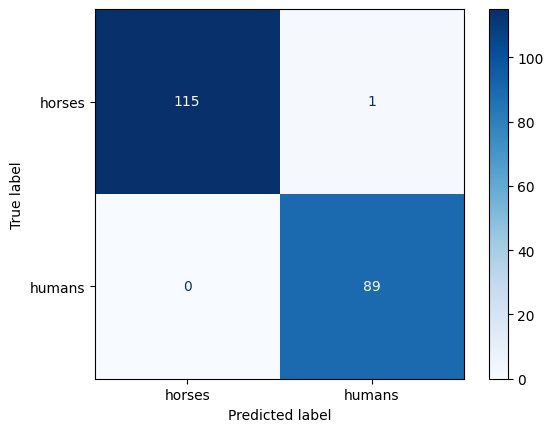

In [11]:
predictions = model.predict(test_batches)
predicted_classes = (predictions > 0.5).astype("int32").flatten()

# Collect true labels from the test set
true_labels = []
for images, labels in test_batches:
    true_labels.extend(labels.numpy())

# Compute confusion matrix
cm = confusion_matrix(true_labels, predicted_classes)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['horses', 'humans'])
disp.plot(cmap=plt.cm.Blues)
plt.show()